# Real World Classification

## Data Preprocessing

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz
# !pip install seaborn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Replace the missing values using “Nearest Neighbors Imputation”
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

## Model Training

In [5]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

In [6]:
# Use the LinearModel to fit the data
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from sklearn.base import BaseEstimator, ClassifierMixin

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)

# Define Linear Model Wrapper
class LinearModelWrapper(BaseEstimator, ClassifierMixin):

    def __init__(self, lr=0.1, reg_lambda=0.01):
        self.lr = lr
        self.reg_lambda = reg_lambda

    def fit(self, X_train, y_train):
        self.model_ = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )

        self.model_.fit(
            X_train, 
            y_train,
            lr=self.lr,
            n_iteration=10000,
            val_ratio=0.2,
            reg_type='l2',
            reg_lambda=self.reg_lambda,
        )
        
        return self

    def predict(self, X):
        return self.model_.predict(X)

In [7]:
from sklearn.model_selection import KFold, cross_val_score

# Hyperparameters
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

results = pd.DataFrame(
    index=[f"lr={lr}" for lr in learning_rates],
    columns=[f"reg_lambda={reg}" for reg in reg_lambdas]
)

for lr in learning_rates:
    for reg in reg_lambdas:

        scores = cross_val_score(
            LinearModelWrapper(lr=lr, reg_lambda=reg),
            X_train,
            y_train,
            cv=KFold(n_splits=5, shuffle=True, random_state=40),
            scoring='accuracy'
        )
        
        results.loc[f"lr={lr}", f"reg_lambda={reg}"] = scores.mean()

results

,reg_lambda=1.0,reg_lambda=2.0,reg_lambda=4.0,reg_lambda=8.0
lr=0.005,0.717143,0.72,0.725714,0.722857
lr=0.01,0.722857,0.728571,0.725714,0.717143
lr=0.1,0.722857,0.725714,0.725714,0.717143
lr=0.5,0.722857,0.691429,0.534286,0.465714


For lr=0.01, reg_lambda=2.0 -> accuracy = 0.728571
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


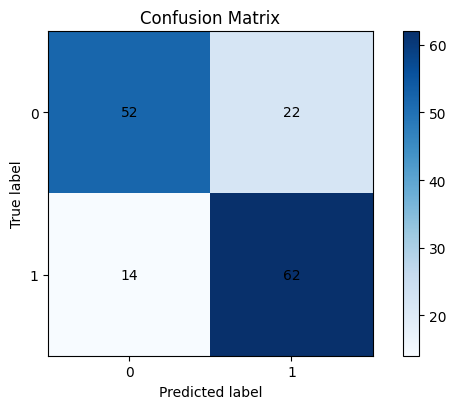

For lr=0.005, reg_lambda=4.0 -> accuracy = 0.725714
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7241
Recall    : 0.8289
F1-score  : 0.7730


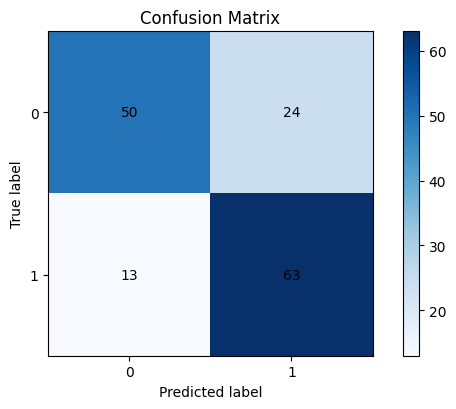

In [8]:
from model.metrics import evaluate_binary_classifier

top2 = results.stack().sort_values(ascending=False).head(2)

for (lr_str, reg_str), score in top2.items():
    print(f"For {lr_str}, {reg_str} -> accuracy = {score:.6f}")

    lr = float(lr_str.replace("lr=", ""))
    reg = float(reg_str.replace("reg_lambda=", ""))

    model = LinearModelWrapper(lr=lr, reg_lambda=reg)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    evaluate_binary_classifier(y_test, y_pred)